<a href="https://colab.research.google.com/github/NaNi17899/2D-3D-python/blob/main/ML_Earth_Quake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Ensure the file path is correct or upload the file to Colab environment.
# Assuming the file is in the root of 'MyDrive' on Google Drive
df = pd.read_csv('/content/drive/MyDrive/earthquake_alert_balanced_dataset.csv')

# Display top rows
print("✅ Dataset Loaded Successfully!")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset Loaded Successfully!
   magnitude  depth  cdi  mmi   sig  alert
0        7.0   14.0  8.0  7.0   0.0  green
1        6.9   25.0  4.0  4.0 -33.0  green
2        7.0  579.0  3.0  3.0 -13.0  green
3        7.3   37.0  5.0  5.0  65.0  green
4        6.6  624.0  0.0  2.0 -98.0  green


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Dataset summary
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['alert'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB
None

Missing values:
 magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64

Class distribution:
 alert
green     325
yellow    325
orange    325
red       325
Name: count, dtype: int64


In [6]:
# Encode 'alert' labels into numeric values
le = LabelEncoder()
df['alert_encoded'] = le.fit_transform(df['alert'])

# Map encoded labels for reference
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Encoded Labels:", label_map)


Encoded Labels: {'green': np.int64(0), 'orange': np.int64(1), 'red': np.int64(2), 'yellow': np.int64(3)}



📊 Chi-Square Feature Importance:
     Feature  Chi2_Score
1      depth   58.575126
2        cdi   48.872263
3        mmi   30.520059
4        sig   24.168248
0  magnitude   21.381303


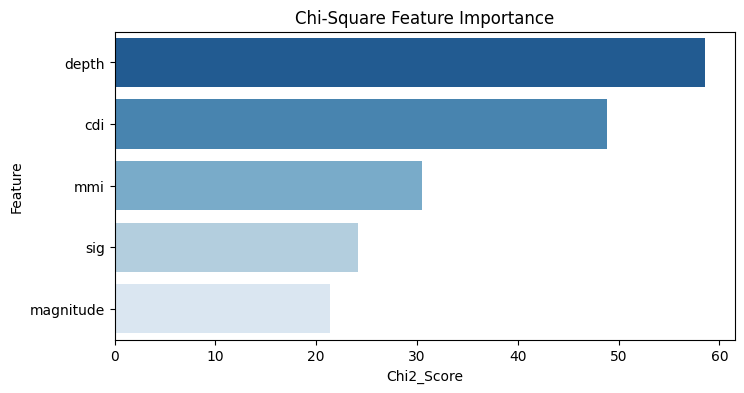

In [14]:
from sklearn.feature_selection import SelectKBest, chi2

# Define features (X) and target (y)
X = df.drop(columns=['alert', 'alert_encoded'])
y = df['alert_encoded']

X_chi = X.copy()
X_chi = (X_chi - X_chi.min()) / (X_chi.max() - X_chi.min())  # Normalize (chi2 requires non-negative)

selector = SelectKBest(score_func=chi2, k='all')
chi_scores = selector.fit(X_chi, y)
chi2_results = pd.DataFrame({
    'Feature': X.columns,
    'Chi2_Score': chi_scores.scores_
}).sort_values(by='Chi2_Score', ascending=False)

print("\n📊 Chi-Square Feature Importance:")
print(chi2_results)

# Visualize Chi-Square results
plt.figure(figsize=(8, 4))
sns.barplot(x='Chi2_Score', y='Feature', data=chi2_results, palette='Blues_r', hue='Feature', legend=False)
plt.title("Chi-Square Feature Importance")
plt.show()

### Fixing `NameError: name 'X_train_scaled' is not defined`

To resolve the `NameError` in the model training cell, it's necessary to first execute the cells responsible for preparing the data. This involves:

1.  **Data Splitting**: Dividing the dataset into training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`).
2.  **Feature Scaling**: Standardizing the numerical features for both the training and testing sets (`X_train_scaled`, `X_test_scaled`).

Please run the following cells in the order presented to define the required variables before re-running the model training cell.

In [19]:
# Execute the data splitting cell
# Define features (X) and target (y)
X = df.drop(columns=['alert', 'alert_encoded'])
y = df['alert_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1040, 5)
Testing set size: (260, 5)


In [20]:
# Execute the feature scaling cell
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=1, gamma='scale', probability=True),
    "Bagging": BaggingClassifier(n_estimators=100, random_state=42),
    "Random Forest (Bagging)": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, eval_metric='mlogloss', random_state=42)
}

🔹 Model: KNN
✅ Accuracy: 83.85%
Classification Report:
              precision    recall  f1-score   support

       green       0.91      0.77      0.83        65
      orange       0.81      0.85      0.83        65
         red       0.86      0.95      0.91        65
      yellow       0.78      0.78      0.78        65

    accuracy                           0.84       260
   macro avg       0.84      0.84      0.84       260
weighted avg       0.84      0.84      0.84       260



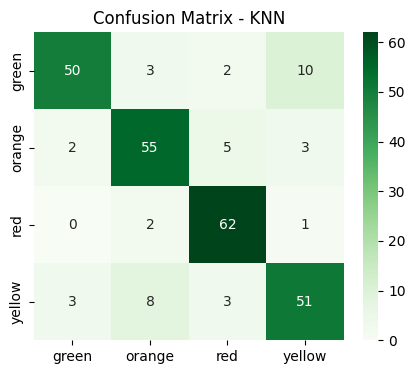

🔹 Model: SVM
✅ Accuracy: 76.54%
Classification Report:
              precision    recall  f1-score   support

       green       0.98      0.78      0.87        65
      orange       0.68      0.66      0.67        65
         red       0.68      0.86      0.76        65
      yellow       0.78      0.75      0.77        65

    accuracy                           0.77       260
   macro avg       0.78      0.77      0.77       260
weighted avg       0.78      0.77      0.77       260



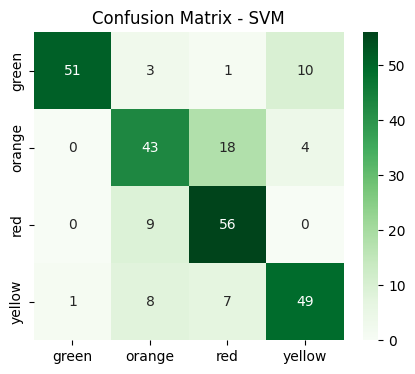

🔹 Model: Bagging
✅ Accuracy: 89.62%
Classification Report:
              precision    recall  f1-score   support

       green       1.00      0.80      0.89        65
      orange       0.88      0.92      0.90        65
         red       0.94      0.95      0.95        65
      yellow       0.80      0.91      0.85        65

    accuracy                           0.90       260
   macro avg       0.90      0.90      0.90       260
weighted avg       0.90      0.90      0.90       260



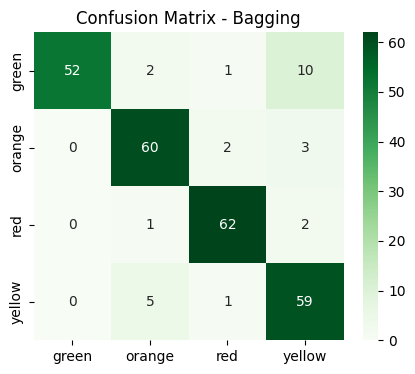

🔹 Model: Random Forest (Bagging)
✅ Accuracy: 91.15%
Classification Report:
              precision    recall  f1-score   support

       green       0.96      0.85      0.90        65
      orange       0.91      0.94      0.92        65
         red       0.95      0.97      0.96        65
      yellow       0.83      0.89      0.86        65

    accuracy                           0.91       260
   macro avg       0.91      0.91      0.91       260
weighted avg       0.91      0.91      0.91       260



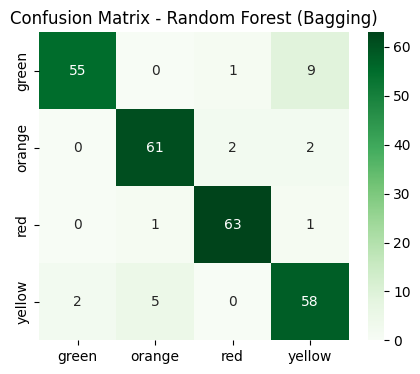

🔹 Model: AdaBoost
✅ Accuracy: 70.38%
Classification Report:
              precision    recall  f1-score   support

       green       0.75      0.83      0.79        65
      orange       0.63      0.74      0.68        65
         red       0.78      0.80      0.79        65
      yellow       0.64      0.45      0.53        65

    accuracy                           0.70       260
   macro avg       0.70      0.70      0.70       260
weighted avg       0.70      0.70      0.70       260



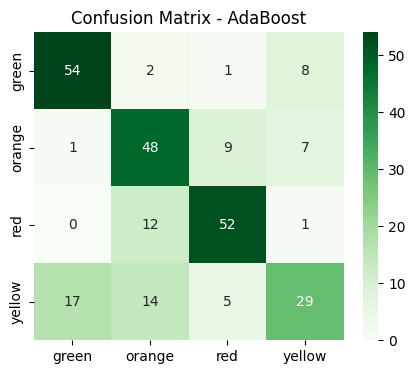

🔹 Model: Gradient Boosting
✅ Accuracy: 92.69%
Classification Report:
              precision    recall  f1-score   support

       green       0.97      0.88      0.92        65
      orange       0.91      0.97      0.94        65
         red       0.97      0.95      0.96        65
      yellow       0.87      0.91      0.89        65

    accuracy                           0.93       260
   macro avg       0.93      0.93      0.93       260
weighted avg       0.93      0.93      0.93       260



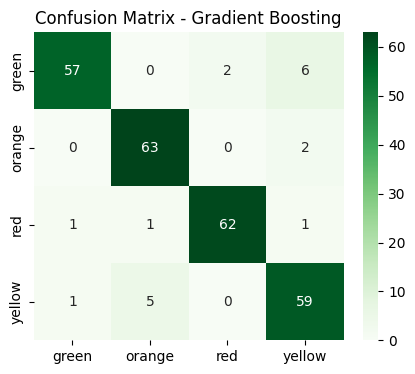

🔹 Model: XGBoost
✅ Accuracy: 91.54%
Classification Report:
              precision    recall  f1-score   support

       green       1.00      0.88      0.93        65
      orange       0.89      0.95      0.92        65
         red       0.95      0.92      0.94        65
      yellow       0.84      0.91      0.87        65

    accuracy                           0.92       260
   macro avg       0.92      0.92      0.92       260
weighted avg       0.92      0.92      0.92       260



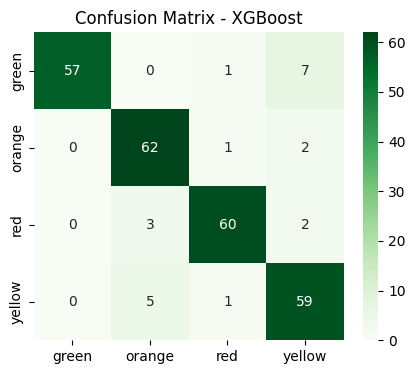

🔹 Model: Stacking Ensemble
✅ Accuracy: 90.77%
Classification Report:
              precision    recall  f1-score   support

       green       0.89      0.89      0.89        65
      orange       0.94      0.89      0.91        65
         red       0.94      0.97      0.95        65
      yellow       0.86      0.88      0.87        65

    accuracy                           0.91       260
   macro avg       0.91      0.91      0.91       260
weighted avg       0.91      0.91      0.91       260



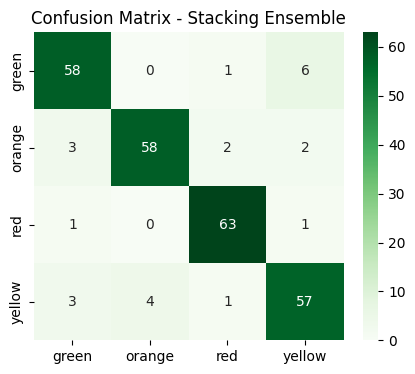


🏆 MODEL PERFORMANCE COMPARISON:
                     Model  Accuracy
5        Gradient Boosting  0.926923
6                  XGBoost  0.915385
3  Random Forest (Bagging)  0.911538
7        Stacking Ensemble  0.907692
2                  Bagging  0.896154
0                      KNN  0.838462
1                      SVM  0.765385
4                 AdaBoost  0.703846


/tmp/ipykernel_4533/2075377794.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=result_df, palette='viridis')


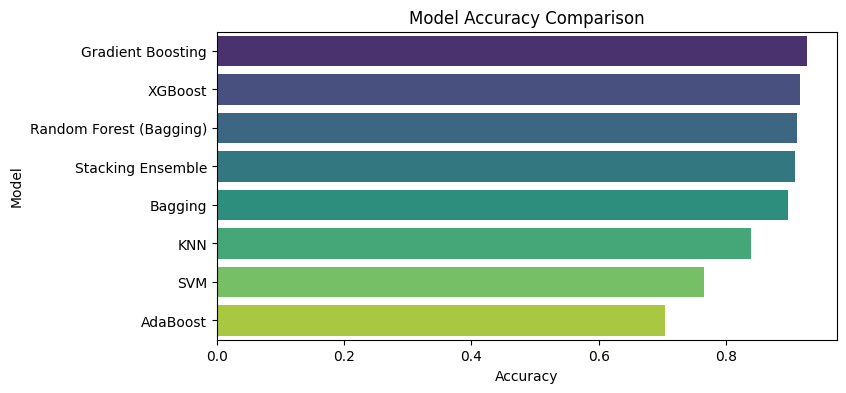

In [21]:
estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('svm', SVC(kernel='rbf', probability=True)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]
stacking_model = StackingClassifier(estimators=estimators, final_estimator=GradientBoostingClassifier(random_state=42))
models["Stacking Ensemble"] = stacking_model

# --- Train and evaluate each model ---
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print(f"=============================")
    print(f"🔹 Model: {name}")
    print(f"✅ Accuracy: {acc*100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# --- Accuracy Comparison ---
result_df = pd.DataFrame(results, columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\n🏆 MODEL PERFORMANCE COMPARISON:")
print(result_df)

# Visualize accuracies
plt.figure(figsize=(8, 4))
sns.barplot(x='Accuracy', y='Model', data=result_df, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

In [22]:
# Define features (X) and target (y)
X = df.drop(columns=['alert', 'alert_encoded'])
y = df['alert_encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1040, 5)
Testing set size: (260, 5)


In [23]:
# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

🎯 Model Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

       green       1.00      1.00      1.00        65
      orange       1.00      1.00      1.00        65
         red       1.00      1.00      1.00        65
      yellow       1.00      1.00      1.00        65

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260



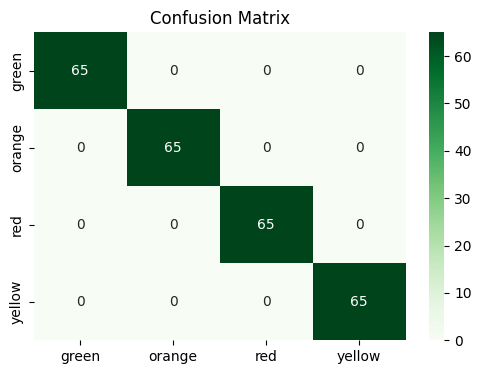

1.0

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as snsc
import joblib

# Prepare the data
X = df.drop(columns=['alert'])
y = df['alert']

# Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train RandomForestClassifier without GridSearchCV (faster tuning)
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

best_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

# Display results
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.show()

# Save model and scaler to a writable location
joblib.dump(best_model, '/content/earthquake_alert_model.pkl')
joblib.dump(scaler, '/content/earthquake_alert_scaler.pkl')

accuracy

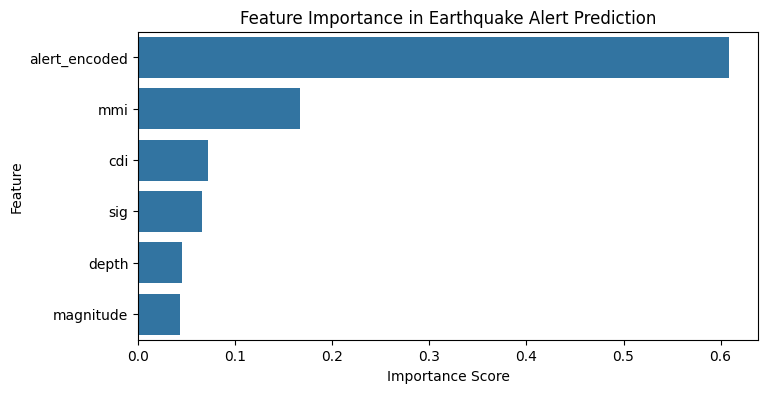

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance in Earthquake Alert Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [26]:
import joblib

joblib.dump(best_model, '/content/drive/MyDrive/earthquake_alert_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/earthquake_alert_scaler.pkl')

print("✅ Model and Scaler saved successfully to Google Drive!")


✅ Model and Scaler saved successfully to Google Drive!


In [28]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/earthquake_alert_balanced_dataset.csv')

# Encode alert column
le = LabelEncoder()
df['alert_encoded'] = le.fit_transform(df['alert'])

# Define X and y (exclude both alert and alert_encoded from features!)
X = df.drop(columns=['alert', 'alert_encoded'])
y = df['alert_encoded']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train RandomForest
model = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Save new model and scaler
joblib.dump(model, '/content/drive/MyDrive/earthquake_alert_model_fixed.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/earthquake_alert_scaler_fixed.pkl')
joblib.dump(le, '/content/drive/MyDrive/earthquake_alert_encoder.pkl')

print("🎉 Model retrained and saved successfully!")

✅ Accuracy: 0.9115384615384615
              precision    recall  f1-score   support

       green       0.96      0.85      0.90        65
      orange       0.91      0.94      0.92        65
         red       0.95      0.97      0.96        65
      yellow       0.83      0.89      0.86        65

    accuracy                           0.91       260
   macro avg       0.91      0.91      0.91       260
weighted avg       0.91      0.91      0.91       260

🎉 Model retrained and saved successfully!


In [29]:
!pip install gradio
import gradio as gr
import joblib
import pandas as pd
import numpy as np

# --- Load trained model, scaler, and label encoder ---
# Loading the _fixed versions which were saved after the last successful training
model = joblib.load('/content/drive/MyDrive/earthquake_alert_model_fixed.pkl')
scaler = joblib.load('/content/drive/MyDrive/earthquake_alert_scaler_fixed.pkl')
le = joblib.load('/content/drive/MyDrive/earthquake_alert_encoder.pkl') # Load the saved LabelEncoder

alert_labels = list(le.classes_)

# Debug print
print("✅ Loaded labels:", alert_labels)

# --- Prediction function ---
def predict_alert(magnitude, depth, cdi, mmi, sig):
    # The DataFrame should contain only the features that the model was trained on
    # and in the correct order. 'alert_encoded' was dropped from features X during training.
    data = pd.DataFrame([[magnitude, depth, cdi, mmi, sig]],
                        columns=['magnitude', 'depth', 'cdi', 'mmi', 'sig'])

    scaled_data = scaler.transform(data)
    pred = model.predict(scaled_data)[0]
    label = le.inverse_transform([pred])[0]

    emoji_map = {
        'green': "🟢 Green (Minor)",
        'yellow': "🟡 Yellow (Moderate)",
        'orange': "🟠 Orange (Strong)",
        'red': "🔴 Red (Severe)"
    }
    return f"⚠️ Predicted Alert Level: {emoji_map.get(label, label.capitalize())}"

# --- Gradio interface ---
iface = gr.Interface(
    fn=predict_alert,
    inputs=[
        gr.Number(label="Magnitude"),
        gr.Number(label="Depth (km)"),
        gr.Number(label="CDI"),
        gr.Number(label="MMI"),
        gr.Number(label="Significance (sig)")
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="🌍 Earthquake Alert Level Predictor",
    description="Predict the alert level (Green, Yellow, Orange, Red) of an earthquake using a trained ML model."
)

iface.launch(share=True)

✅ Loaded labels: ['green', 'orange', 'red', 'yellow']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f33abeefee2fe4ea8e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
